In [3]:
# read data
PROJECT_ROOT = Path("/Users/xueqingliu/Harvard University Dropbox/Liu Xueqing/ADAPR-MRT-Testbed")
COMBINED_DIR = Path("/Users/xueqingliu/Harvard University Dropbox/Liu Xueqing/ADAPT_MRT/rawdata/_combined")
WORK_DIR = PROJECT_ROOT / "env_para_vanilla"
WORK_DIR.mkdir(parents=True, exist_ok=True)


# Aliases for later cells that use `folder` / `work_folder` (Path so `/` joins work)
folder = COMBINED_DIR
work_folder = Path(WORK_DIR)

df_fit = pd.read_csv(folder / 'df_fit.csv')

In [4]:
# %%
# user 141, 143 does not have week 0, change week 0 to week 1
# change all participants' who have more than 2 week 0 to week 1
for userid in df_fit['ParticipantIdentifier'].unique():
    vc = df_fit.loc[df_fit['ParticipantIdentifier'] == userid, 'week'].value_counts()
    if vc.get(0, 0) > 2:
        m = df_fit['ParticipantIdentifier'] == userid
        df_fit.loc[m, 'week'] = df_fit.loc[m, 'week'] + 1
# remove week 12
df_fit = df_fit[df_fit['week'] < 13]
print(df_fit.week.unique())



[ 1  2  3  4  5  6  7  8  9 10 11 12]


In [ ]:
# change it from 0-7 to 1-8
df_fit['Exp-tool-1'] = df_fit['Exp-tool-1'] + 1
df_fit['Exp-tool-2'] = df_fit['Exp-tool-2'] + 1

# Per week: sums over distinct days (daily_present; DayWearing duplicated across DecisionTime)
_weekly_daily = (
    df_fit.assign(_d=pd.to_datetime(df_fit['Date']))
    .groupby(['ParticipantIdentifier', 'week', '_d'], as_index=False)[['daily_present', 'morning_wearing', 'DailyPageviewCount']]
    .first()
    .groupby(['ParticipantIdentifier', 'week'])[['daily_present', 'morning_wearing', 'DailyPageviewCount']]
    .sum()
    .rename(columns={'daily_present': 'weekly_daily_present_sum', 'morning_wearing': 'weekly_daily_wearing_sum', 'DailyPageviewCount': 'weekly_daily_pageview_sum'})
    .reset_index()
)

df_fit = df_fit.merge(_weekly_daily, on=['ParticipantIdentifier', 'week'], how='left')

# min–max to [0, 1]: (x - min) / (max - min); constant column → 0
_pv = df_fit['weekly_daily_pageview_sum']
_lo, _hi = _pv.min(), _pv.max()
df_fit['weekly_daily_pageview_sum'] = (_pv - _lo) / (_hi - _lo) if _hi > _lo else 0.0

# # print(df_fit.weekly_daily_pageview_sum.unique())
# df_fit['perceived_utility'] = (
#     w_1 * df_fit['week_present']
#     + 0.5 * (w_2/8) * df_fit['week_present'] * (df_fit['Exp-tool-1'] + df_fit['Exp-tool-2'])
#     + (w_3 / 7) * df_fit['weekly_daily_present_sum']
#     + (w_4 / 7) * df_fit['weekly_daily_wearing_sum']
#     + (w_5) * df_fit['weekly_daily_pageview_sum']
# )

# # add perceived utility last week
# df_fit['perceived_utility_lastweek'] = df_fit['perceived_utility'].shift(1)


In [6]:
obs_dim = 3    # emission dimension
state_dim = 1   # latent state dimension
input_dim = 3    # input dimension
N_iters = 10

  0%|          | 0/1 [00:00<?, ?it/s]

Initializing with an ARHMM using 25 steps of EM.


  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

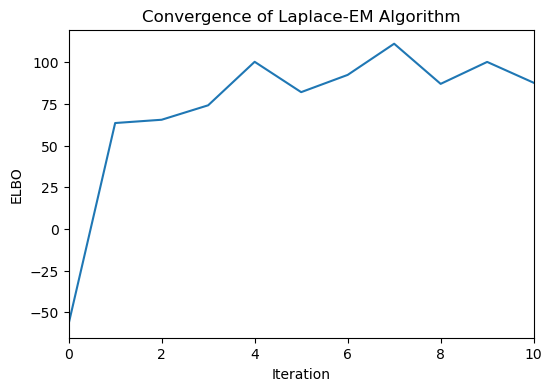

-0.014721631202294722
((array([0.]),), (array([[0.]]),), (array([[[0.28645222]]]), array([[1.43970042e-09]]), array([[[ 0.07840231,  0.01632023, -0.19620383]]]), array([[[0.28733921]]])), (array([[[ 0.90959271],
        [-0.0264624 ],
        [-0.04483473]]]), array([[[ 0.59581774,  0.08888904,  0.39349597],
        [-0.01172158,  0.12766283, -0.04360953],
        [ 0.02330598,  0.12217947, -0.05447412]]]), array([[0.20400687, 0.67518791, 0.67309365]]), array([[-2.71923655, -3.71225256, -3.73565465]])))


In [9]:
# initialize parameters
np.random.seed(2026)
# input matrix u
weekly_daily_present = df_fit['weekly_daily_present_sum'] / 7
weekly_daily_wearing = df_fit['weekly_daily_wearing_sum'] / 7
weekly_daily_pageview = df_fit['weekly_daily_pageview_sum']

# fill nan with mean
weekly_daily_present = weekly_daily_present.fillna(weekly_daily_present.mean())
weekly_daily_wearing = weekly_daily_wearing.fillna(weekly_daily_wearing.mean())
weekly_daily_pageview = weekly_daily_pageview.fillna(weekly_daily_pageview.mean())

# to weekly level
weekly_daily_present = weekly_daily_present.to_numpy().reshape(-1, 14)[:, 0]
weekly_daily_wearing = weekly_daily_wearing.to_numpy().reshape(-1, 14)[:, 0]
weekly_daily_pageview = weekly_daily_pageview.to_numpy().reshape(-1, 14)[:, 0]

u = np.stack([weekly_daily_present, weekly_daily_wearing, weekly_daily_pageview], axis=1)

# observation matrix y
weekly_present = df_fit['week_present']
weekly_exp1 = df_fit['Exp-tool-1'] / 8
weekly_exp2 = df_fit['Exp-tool-2'] / 8  

# fill nan with mean
weekly_present = weekly_present.fillna(weekly_present.mean())
weekly_exp1 = weekly_exp1.fillna(weekly_exp1.mean())
weekly_exp2 = weekly_exp2.fillna(weekly_exp2.mean())

# to weekly level
weekly_present = weekly_present.to_numpy().reshape(-1, 14)[:, 0]
weekly_exp1 = weekly_exp1.to_numpy().reshape(-1, 14)[:, 0]
weekly_exp2 = weekly_exp2.to_numpy().reshape(-1, 14)[:, 0]

y = np.stack([weekly_present, weekly_exp1, weekly_exp2], axis=1)

lds = ssm.LDS(
    N=obs_dim, D=state_dim, M=input_dim, dynamics_kwargs={"l2_penalty_b": 1e8}, 
    transitions="inputdriven", dynamics="gaussian", emissions="gaussian"
)

lds_lps, lds_q = lds.fit(
    y, u, 
    method="laplace_em", num_iters=N_iters, initialize=True
)

plt.figure(figsize=(6, 4))
plt.plot(lds_lps, label="Laplace-EM")
plt.xlim(0, N_iters)
plt.xlabel("Iteration")
plt.ylabel("ELBO")
plt.title("Convergence of Laplace-EM Algorithm")
# plt.savefig(PROJECT_ROOT + 'LDS_initilization_EM_V'  + '.pdf')
plt.show()

print(np.mean(lds_q.mean_continuous_states[0]))
print(lds.params)
As_init, bs_init, Vs_init, sqrt_Sigmas_init = lds.dynamics.params
Cs_init, Fs_init, ds_init, inv_etas_init = lds.emissions.params

In [11]:
userid_all = df_fit['ParticipantIdentifier'].unique()
perceived_utility_by_user = {}
for i, userid in enumerate(userid_all):
    dat_user = df_fit[df_fit['ParticipantIdentifier'] == userid].copy()
    dat_user = dat_user.sort_values(['Date', 'DecisionTime'], na_position='last').reset_index(drop=True)

    # Input matrix u
    weekly_daily_present = dat_user['weekly_daily_present_sum'] / 7
    weekly_daily_wearing = dat_user['weekly_daily_wearing_sum'] / 7
    weekly_daily_pageview = dat_user['weekly_daily_pageview_sum']

    # fill nan with mean
    weekly_daily_present = weekly_daily_present.fillna(weekly_daily_present.mean())
    weekly_daily_wearing = weekly_daily_wearing.fillna(weekly_daily_wearing.mean())
    weekly_daily_pageview = weekly_daily_pageview.fillna(weekly_daily_pageview.mean())

    # to weekly level
    weekly_daily_present = weekly_daily_present.to_numpy().reshape(-1, 14)[:, 0]
    weekly_daily_wearing = weekly_daily_wearing.to_numpy().reshape(-1, 14)[:, 0]
    weekly_daily_pageview = weekly_daily_pageview.to_numpy().reshape(-1, 14)[:, 0]

    u = np.stack([weekly_daily_present, weekly_daily_wearing, weekly_daily_pageview], axis=1)

    # Observation matrix y
    weekly_present = dat_user['week_present']
    weekly_exp1 = dat_user['Exp-tool-1'] / 8
    weekly_exp2 = dat_user['Exp-tool-2'] / 8 

    # fill nan with mean
    weekly_present = weekly_present.fillna(weekly_present.mean())
    weekly_exp1 = weekly_exp1.fillna(weekly_exp1.mean())
    weekly_exp2 = weekly_exp2.fillna(weekly_exp2.mean())

    # to weekly level
    weekly_present = weekly_present.to_numpy().reshape(-1, 14)[:, 0]
    weekly_exp1 = weekly_exp1.to_numpy().reshape(-1, 14)[:, 0]
    weekly_exp2 = weekly_exp2.to_numpy().reshape(-1, 14)[:, 0]

    y = np.stack([weekly_present, weekly_exp1, weekly_exp2], axis=1)

    # set initial state
    perceived_utility_init = 1

    # use the ssm package to fit the data
    lds = ssm.LDS(
        N=obs_dim, D=state_dim, M=input_dim,
        transitions="inputdriven", dynamics="gaussian", emissions="gaussian"
    )

    lds.dynamics._As = As_init
    lds.dynamics.bs = bs_init
    lds.dynamics.Vs = Vs_init
    lds.dynamics._sqrt_Sigmas = sqrt_Sigmas_init
    lds.emissions._Cs = Cs_init
    lds.emissions.Fs = Fs_init
    lds.emissions.ds = ds_init
    lds.emissions.inv_etas = inv_etas_init
    lds_lps, lds_q = lds.fit(
        y, inputs=u, 
        method="laplace_em", num_iters=N_iters, initialize=False
    )

    # perceived utility (one value per LDS timestep; map to df rows with np.repeat)
    perceived_utility = lds_q.mean_continuous_states[0].reshape(-1)
    perceived_utility_by_user[userid] = np.asarray(perceived_utility, dtype=float)


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

In [13]:
print(perceived_utility)

[-0.48799908 -0.22008035 -0.1622133  -0.10698362 -0.09850995 -0.02329285
 -0.05336922  0.07223051  0.05593954  0.03418391  0.05477736  0.11028922]


In [ ]:
# Lag-1 within each participant (global [:-1] misaligns rows and crosses participants)

# add perceived utility for each user (from LDS cell: perceived_utility_by_user)
for userid in df_fit['ParticipantIdentifier'].unique():
    pu = perceived_utility_by_user[userid]
    m = df_fit['ParticipantIdentifier'] == userid
    n = int(m.sum())
    reps = n // len(pu)
    if n % len(pu) != 0:
        raise ValueError(
            f"Participant {userid}: {n} rows not divisible by LDS length {len(pu)}"
        )
    df_fit.loc[m, 'perceived_utility'] = np.repeat(pu, reps)

# add last week's perceived utility
df_fit['perceived_utility_lastweek'] = df_fit['perceived_utility'].shift(1)

# remove week 0 and week 1 data
df_fit = df_fit[df_fit['week'] > 1]

# turn week 2 into week 1
df_fit['week'] = df_fit['week'] - 1


df_fit.to_csv(folder / "df_fit_11week.csv")